# 1.4 With Events (8 Hours Lag) Table EDA

Exploratory data analysis for the `eaglei_outages_with_events_*_8_hours_lag.csv` files.

These tables contain outages linked to events with an 8-hour lag window for event attribution.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Load all 8 hours lag files
data_dir = Path("../../data/raw/introduction/Outage_Dataset")
lag_files = list(data_dir.glob("*_8_hours_lag.csv"))

print(f"Found {len(lag_files)} 8-hour lag files")
for f in sorted(lag_files):
    print(f"  - {f.name}")

Found 10 8-hour lag files
  - eaglei_outages_with_events_2014_8_hours_lag.csv
  - eaglei_outages_with_events_2015_8_hours_lag.csv
  - eaglei_outages_with_events_2016_8_hours_lag.csv
  - eaglei_outages_with_events_2017_8_hours_lag.csv
  - eaglei_outages_with_events_2018_8_hours_lag.csv
  - eaglei_outages_with_events_2019_8_hours_lag.csv
  - eaglei_outages_with_events_2020_8_hours_lag.csv
  - eaglei_outages_with_events_2021_8_hours_lag.csv
  - eaglei_outages_with_events_2022_8_hours_lag.csv
  - eaglei_outages_with_events_2023_8_hours_lag.csv


In [3]:
# Load and combine all data
dfs = [pd.read_csv(f) for f in lag_files]
df = pd.concat(dfs, ignore_index=True)

print(f"Total rows: {len(df):,}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Total rows: 91,402

Columns: ['event_id', 'state_event', 'Datetime Event Began', 'Datetime Restoration', 'Event Type', 'fips', 'state', 'county', 'start_time', 'duration', 'min_customers', 'max_customers', 'mean_customers']


,event_id,state_event,Datetime Event Began,Datetime Restoration,Event Type,fips,state,county,start_time,duration,min_customers,max_customers,mean_customers
0,Alabama-0,Alabama,2017-01-22 16:00:00,2017-01-23 03:26:00,Severe Weather,1001,Alabama,Autauga,2017-01-22 19:15:00,0.25,259.0,259.0,259.000000
1,Alabama-0,Alabama,2017-01-22 16:00:00,2017-01-23 03:26:00,Severe Weather,1001,Alabama,Autauga,2017-01-22 20:00:00,3.50,213.0,1175.0,387.357143
2,Alabama-0,Alabama,2017-01-22 16:00:00,2017-01-23 03:26:00,Severe Weather,1001,Alabama,Autauga,2017-01-23 02:00:00,0.25,269.0,269.0,269.000000
3,Alabama-0,Alabama,2017-01-22 16:00:00,2017-01-23 03:26:00,Severe Weather,1001,Alabama,Autauga,2017-01-23 03:15:00,0.25,254.0,254.0,254.000000
4,Alabama-0,Alabama,2017-01-22 16:00:00,2017-01-23 03:26:00,Severe Weather,1003,Alabama,Baldwin,2017-01-22 17:30:00,0.50,1116.0,1169.0,1142.500000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 91402 entries, 0 to 91401
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   event_id              91402 non-null  str    
 1   state_event           91402 non-null  str    
 2   Datetime Event Began  91402 non-null  str    
 3   Datetime Restoration  91402 non-null  str    
 4   Event Type            91402 non-null  str    
 5   fips                  91402 non-null  int64  
 6   state                 91402 non-null  str    
 7   county                91402 non-null  str    
 8   start_time            91402 non-null  str    
 9   duration              91402 non-null  float64
 10  min_customers         91402 non-null  float64
 11  max_customers         91402 non-null  float64
 12  mean_customers        91402 non-null  float64
dtypes: float64(4), int64(1), str(8)
memory usage: 9.1 MB


In [5]:
df.describe()

,fips,duration,min_customers,max_customers,mean_customers
count,91402.000000,91402.000000,91402.000000,9.140200e+04,9.140200e+04
mean,33038.130938,8.561019,1667.142896,4.301444e+03,2.690306e+03
std,16471.971403,20.067396,10608.776047,2.405643e+04,1.390933e+04
min,1001.000000,0.250000,200.000000,2.000000e+02,2.000000e+02
25%,21187.000000,0.500000,228.000000,3.550000e+02,3.191028e+02
50%,37127.000000,1.750000,322.000000,8.100000e+02,6.295147e+02
75%,48213.000000,6.250000,687.000000,2.307750e+03,1.428632e+03
max,55141.000000,636.750000,808450.000000,1.777800e+06,1.078687e+06


## Event Type Frequency

In [6]:
event_type_counts = df['Event Type'].value_counts()
print(f"Unique event types: {len(event_type_counts)}")
event_type_counts

Unique event types: 69


Event Type
Severe Weather                                                                      64140
System Operations                                                                    4083
Fuel Supply Deficiency                                                               3852
Vandalism                                                                            3495
Severe Weather/Transmission Interruption                                             3145
                                                                                    ...  
- Theft - Suspicious activity                                                           2
 Vandalism                                                                              1
- Failure at high voltage substation or switchyard - Weather or natural disaster        1
- Physical attack - Other                                                               1
Severe Weather- High Winds                                                              1

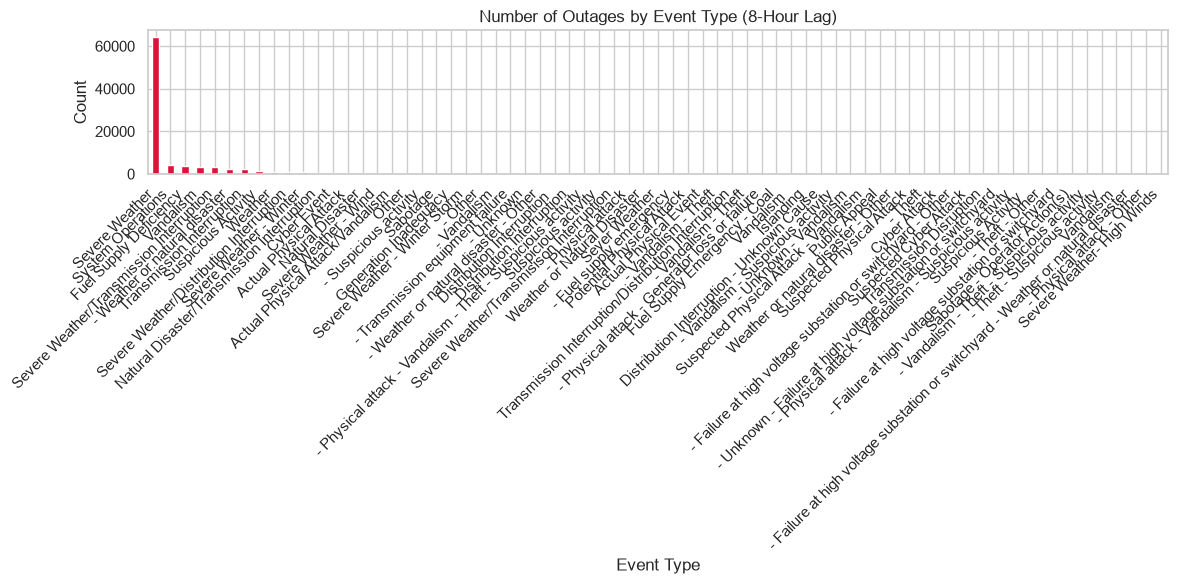

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
event_type_counts.plot(kind='bar', ax=ax, color='crimson')
ax.set_title('Number of Outages by Event Type (8-Hour Lag)')
ax.set_xlabel('Event Type')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

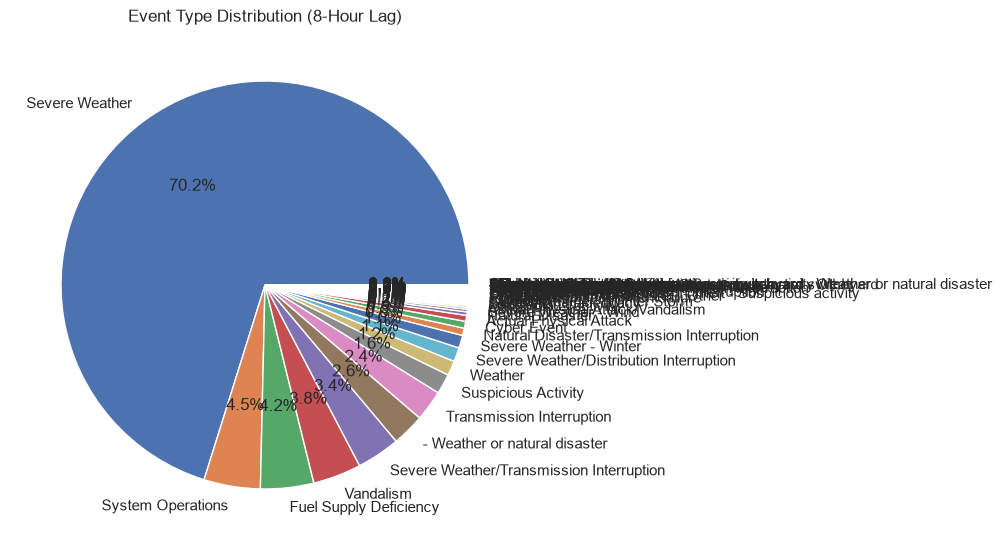

In [8]:
# Pie chart for event type distribution
fig, ax = plt.subplots(figsize=(10, 10))
event_type_counts.plot(kind='pie', ax=ax, autopct='%1.1f%%')
ax.set_title('Event Type Distribution (8-Hour Lag)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## Event ID Frequency

In [9]:
event_id_counts = df['event_id'].value_counts()
print(f"Unique event IDs: {len(event_id_counts)}")
print(f"\nTop 10 events by number of outages:")
event_id_counts.head(10)

Unique event IDs: 615

Top 10 events by number of outages:


event_id
Texas-8          2442
Texas-1          2182
Texas-10         2059
Texas-5          1978
Texas-2          1787
Maryland-1       1751
Texas-9          1718
Texas-3          1714
California-12    1699
Virginia-1       1437
Name: count, dtype: int64

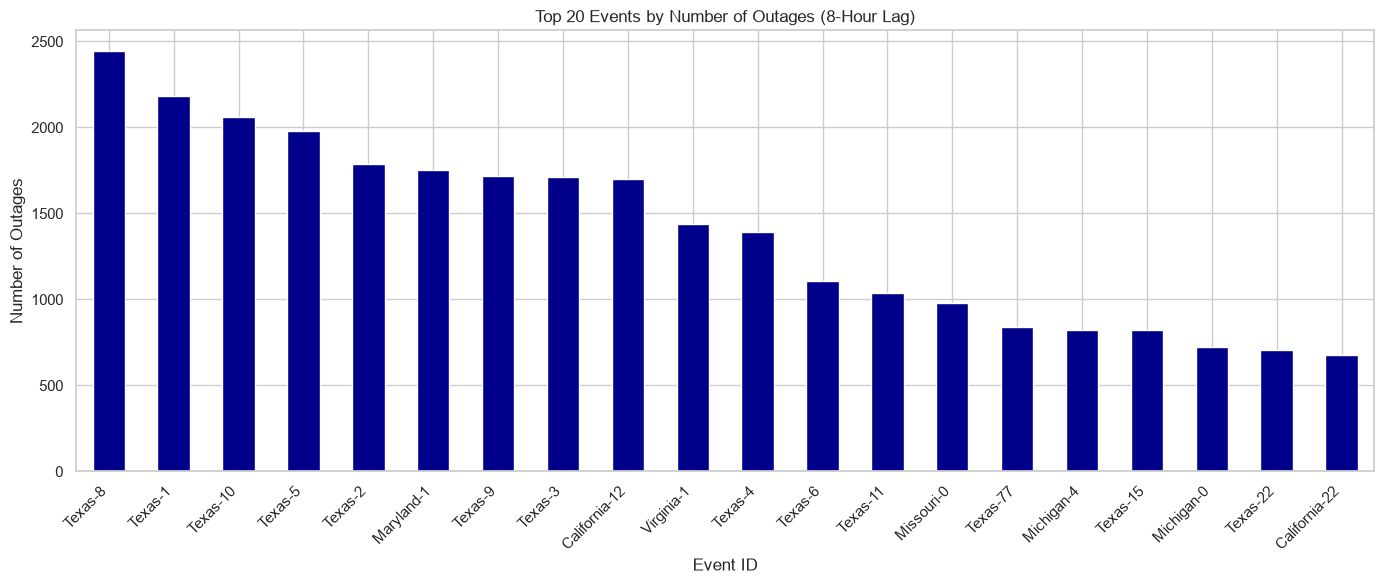

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))
event_id_counts.head(20).plot(kind='bar', ax=ax, color='darkblue')
ax.set_title('Top 20 Events by Number of Outages (8-Hour Lag)')
ax.set_xlabel('Event ID')
ax.set_ylabel('Number of Outages')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## State Frequency

In [11]:
state_counts = df['state'].value_counts()
print(f"Unique states: {len(state_counts)}")
state_counts.head(10)

Unique states: 47


state
Texas             30894
California         9921
Michigan           5092
North Carolina     4629
Louisiana          3389
Georgia            3357
Florida            3126
New York           2823
Virginia           2797
Maryland           2299
Name: count, dtype: int64

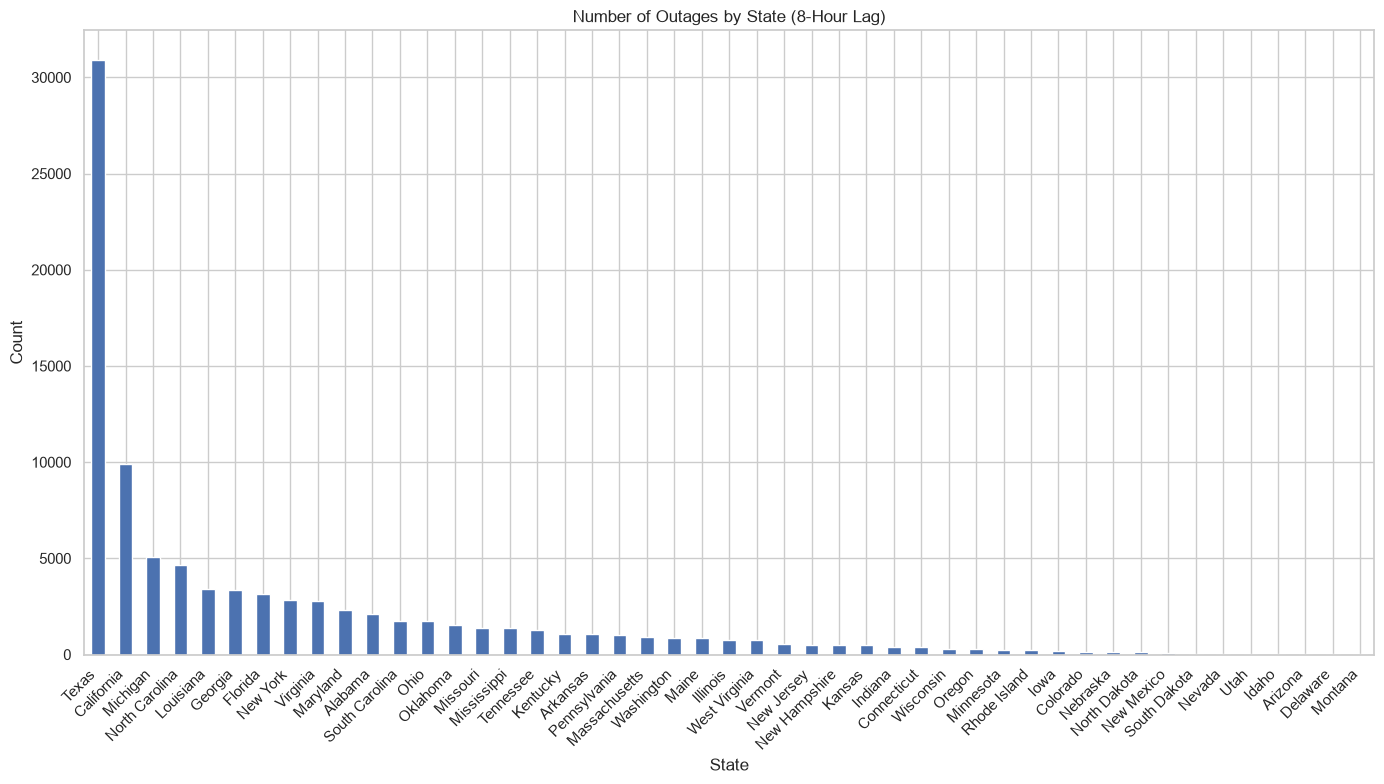

In [12]:
fig, ax = plt.subplots(figsize=(14, 8))
state_counts.plot(kind='bar', ax=ax)
ax.set_title('Number of Outages by State (8-Hour Lag)')
ax.set_xlabel('State')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## County Frequency (Top 20)

In [13]:
county_counts = df['county'].value_counts()
print(f"Unique counties: {len(county_counts)}")
county_counts.head(20)

Unique counties: 1570


county
Baltimore         1962
Rains             1507
Fayette           1221
Roanoke           1116
Orange            1068
Lee                941
Montgomery         902
St. Louis          886
Fort Bend          851
Jefferson          822
Washington         732
Harris             719
Dallas             665
Madison            629
Tarrant            576
Riverside          571
Franklin           543
San Bernardino     539
San Diego          504
Bexar              492
Name: count, dtype: int64

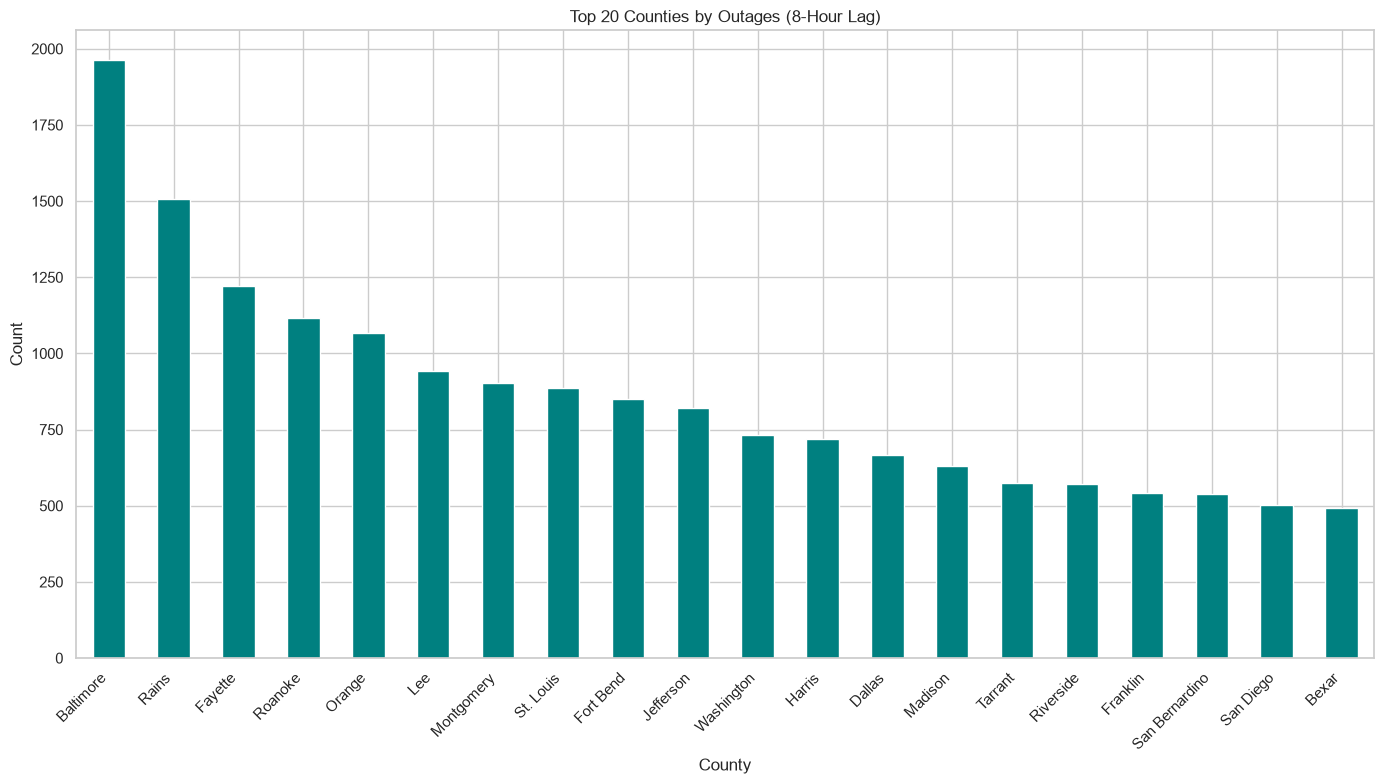

In [14]:
fig, ax = plt.subplots(figsize=(14, 8))
county_counts.head(20).plot(kind='bar', ax=ax, color='teal')
ax.set_title('Top 20 Counties by Outages (8-Hour Lag)')
ax.set_xlabel('County')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Duration Distribution

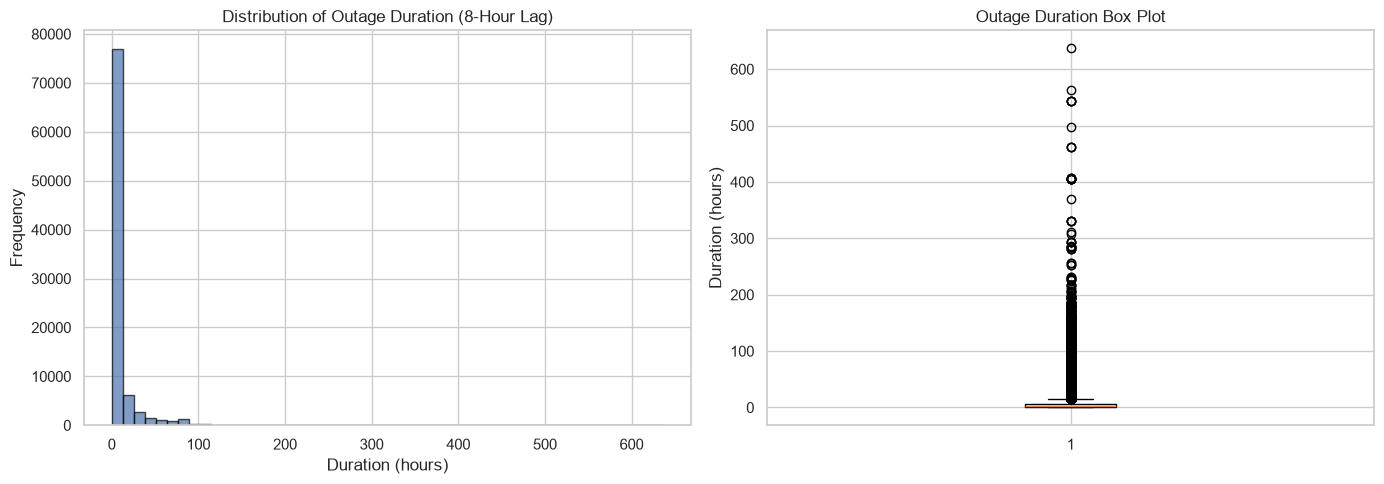

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['duration'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Outage Duration (8-Hour Lag)')
axes[0].set_xlabel('Duration (hours)')
axes[0].set_ylabel('Frequency')

# Box plot
axes[1].boxplot(df['duration'].dropna())
axes[1].set_title('Outage Duration Box Plot')
axes[1].set_ylabel('Duration (hours)')

plt.tight_layout()
plt.show()

## Max Customers Distribution

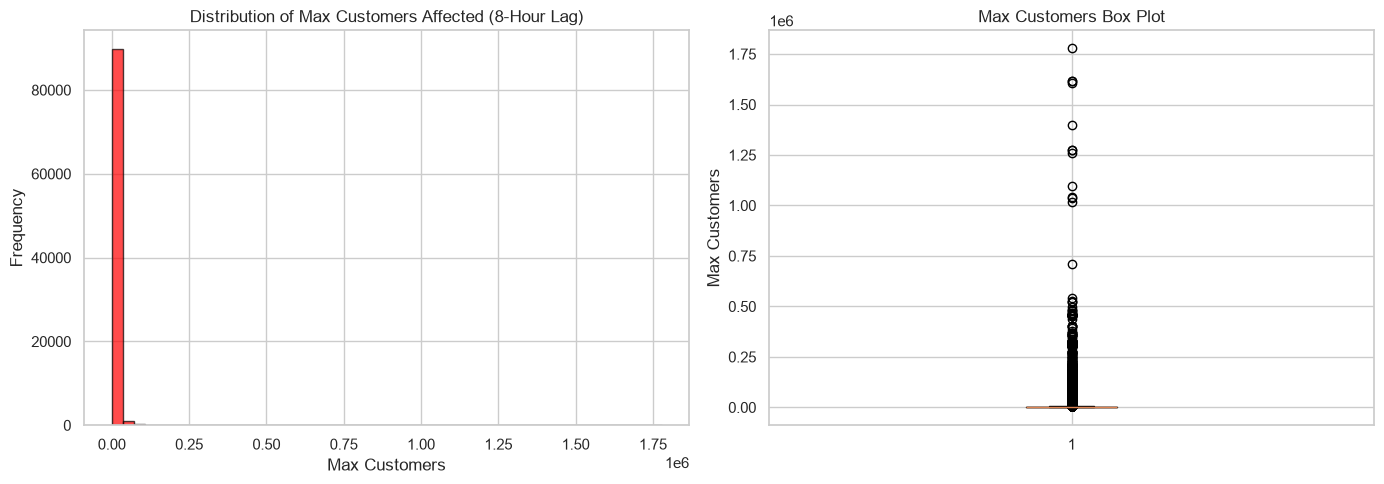

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['max_customers'], bins=50, edgecolor='black', alpha=0.7, color='red')
axes[0].set_title('Distribution of Max Customers Affected (8-Hour Lag)')
axes[0].set_xlabel('Max Customers')
axes[0].set_ylabel('Frequency')

# Box plot
axes[1].boxplot(df['max_customers'].dropna())
axes[1].set_title('Max Customers Box Plot')
axes[1].set_ylabel('Max Customers')

plt.tight_layout()
plt.show()

## Temporal Analysis

In [17]:
# Parse datetime
df['start_time'] = pd.to_datetime(df['start_time'])
df['year'] = df['start_time'].dt.year
df['month'] = df['start_time'].dt.month

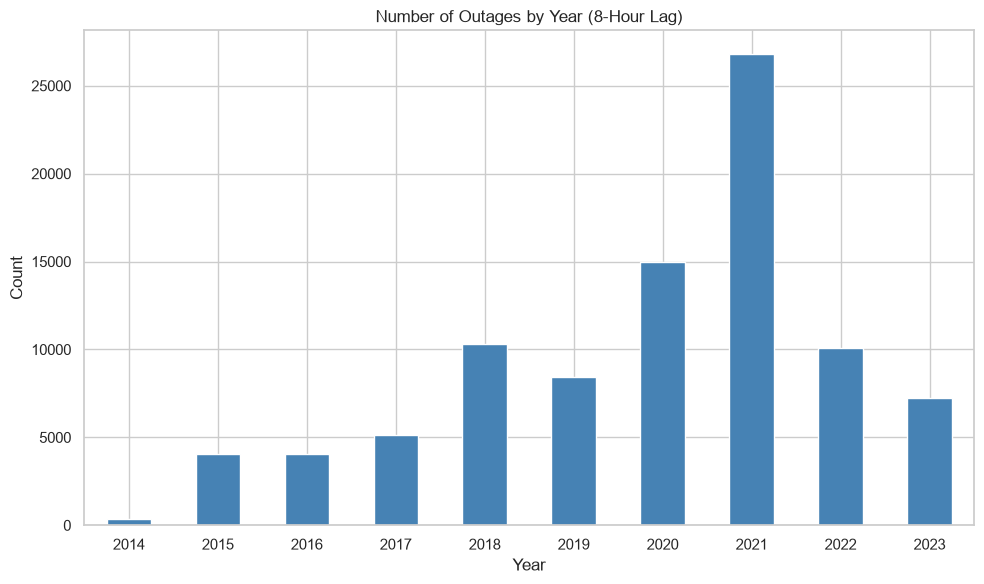

In [18]:
year_counts = df['year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 6))
year_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Number of Outages by Year (8-Hour Lag)')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

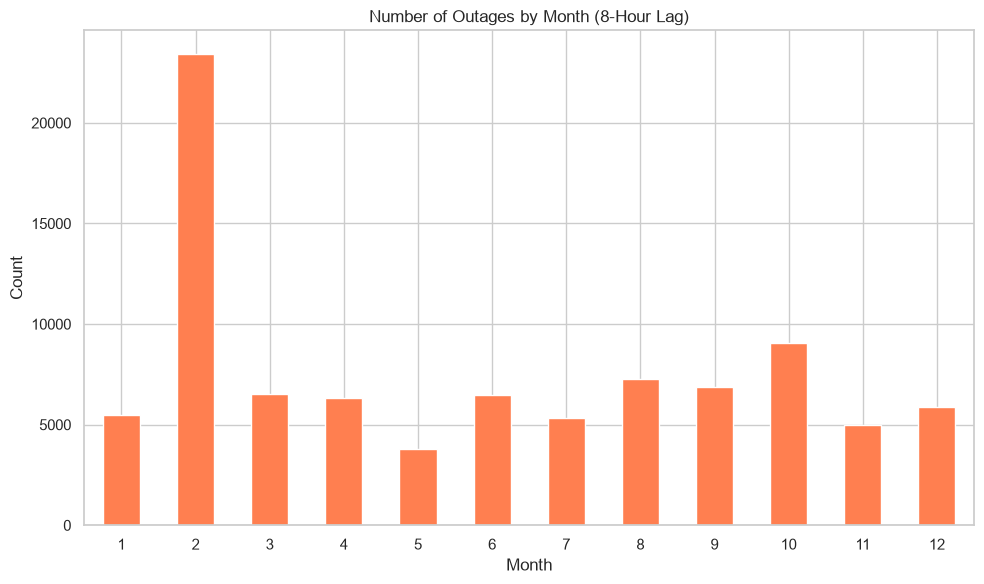

In [19]:
month_counts = df['month'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 6))
month_counts.plot(kind='bar', ax=ax, color='coral')
ax.set_title('Number of Outages by Month (8-Hour Lag)')
ax.set_xlabel('Month')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Event Type by State

In [20]:
# Cross-tabulation of event types by state
event_state_crosstab = pd.crosstab(df['state'], df['Event Type'])
event_state_crosstab.head(10)

Event Type,Vandalism,- Failure at high voltage substation or switchyard,- Failure at high voltage substation or switchyard - Other,- Failure at high voltage substation or switchyard - Weather or natural disaster,- Fuel supply emergency,- Other,- Physical attack,- Physical attack - Generator loss or failure,- Physical attack - Other,- Physical attack - Vandalism - Suspicious activity,...,Suspicious activity,System Operations,Transmission Disruption,Transmission Interruption,Transmission Interruption/Distribution Interruption,Vandalism,Vandalism,Weather,Weather or Natural Disaster,Weather or natural disaster - Other
state,,,,,,,,,,,,,,,,,,,,,
Alabama,0,0,0,0,0,0,0,0,0,0,...,11,7,0,132,0,23,0,21,0,0
Arizona,0,0,0,0,0,0,0,0,0,0,...,0,14,0,0,0,2,0,0,0,0
Arkansas,0,0,0,0,0,0,0,0,0,0,...,0,2,0,35,0,6,0,0,0,0
California,0,0,0,0,31,10,0,0,0,0,...,8,907,4,221,0,1415,0,0,0,0
Colorado,0,0,0,0,0,1,0,0,0,0,...,0,3,0,27,0,7,0,35,0,0
Connecticut,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,22,0,0
Delaware,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Florida,0,0,0,0,0,19,0,0,0,0,...,0,288,0,107,0,146,0,30,0,0
Georgia,0,0,0,0,0,0,0,0,0,0,...,0,6,0,0,0,22,0,83,0,0


/var/folders/rf/67rlpxv97rn3kj1ypyqy5k9c0000gn/T/ipykernel_52210/4021947553.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


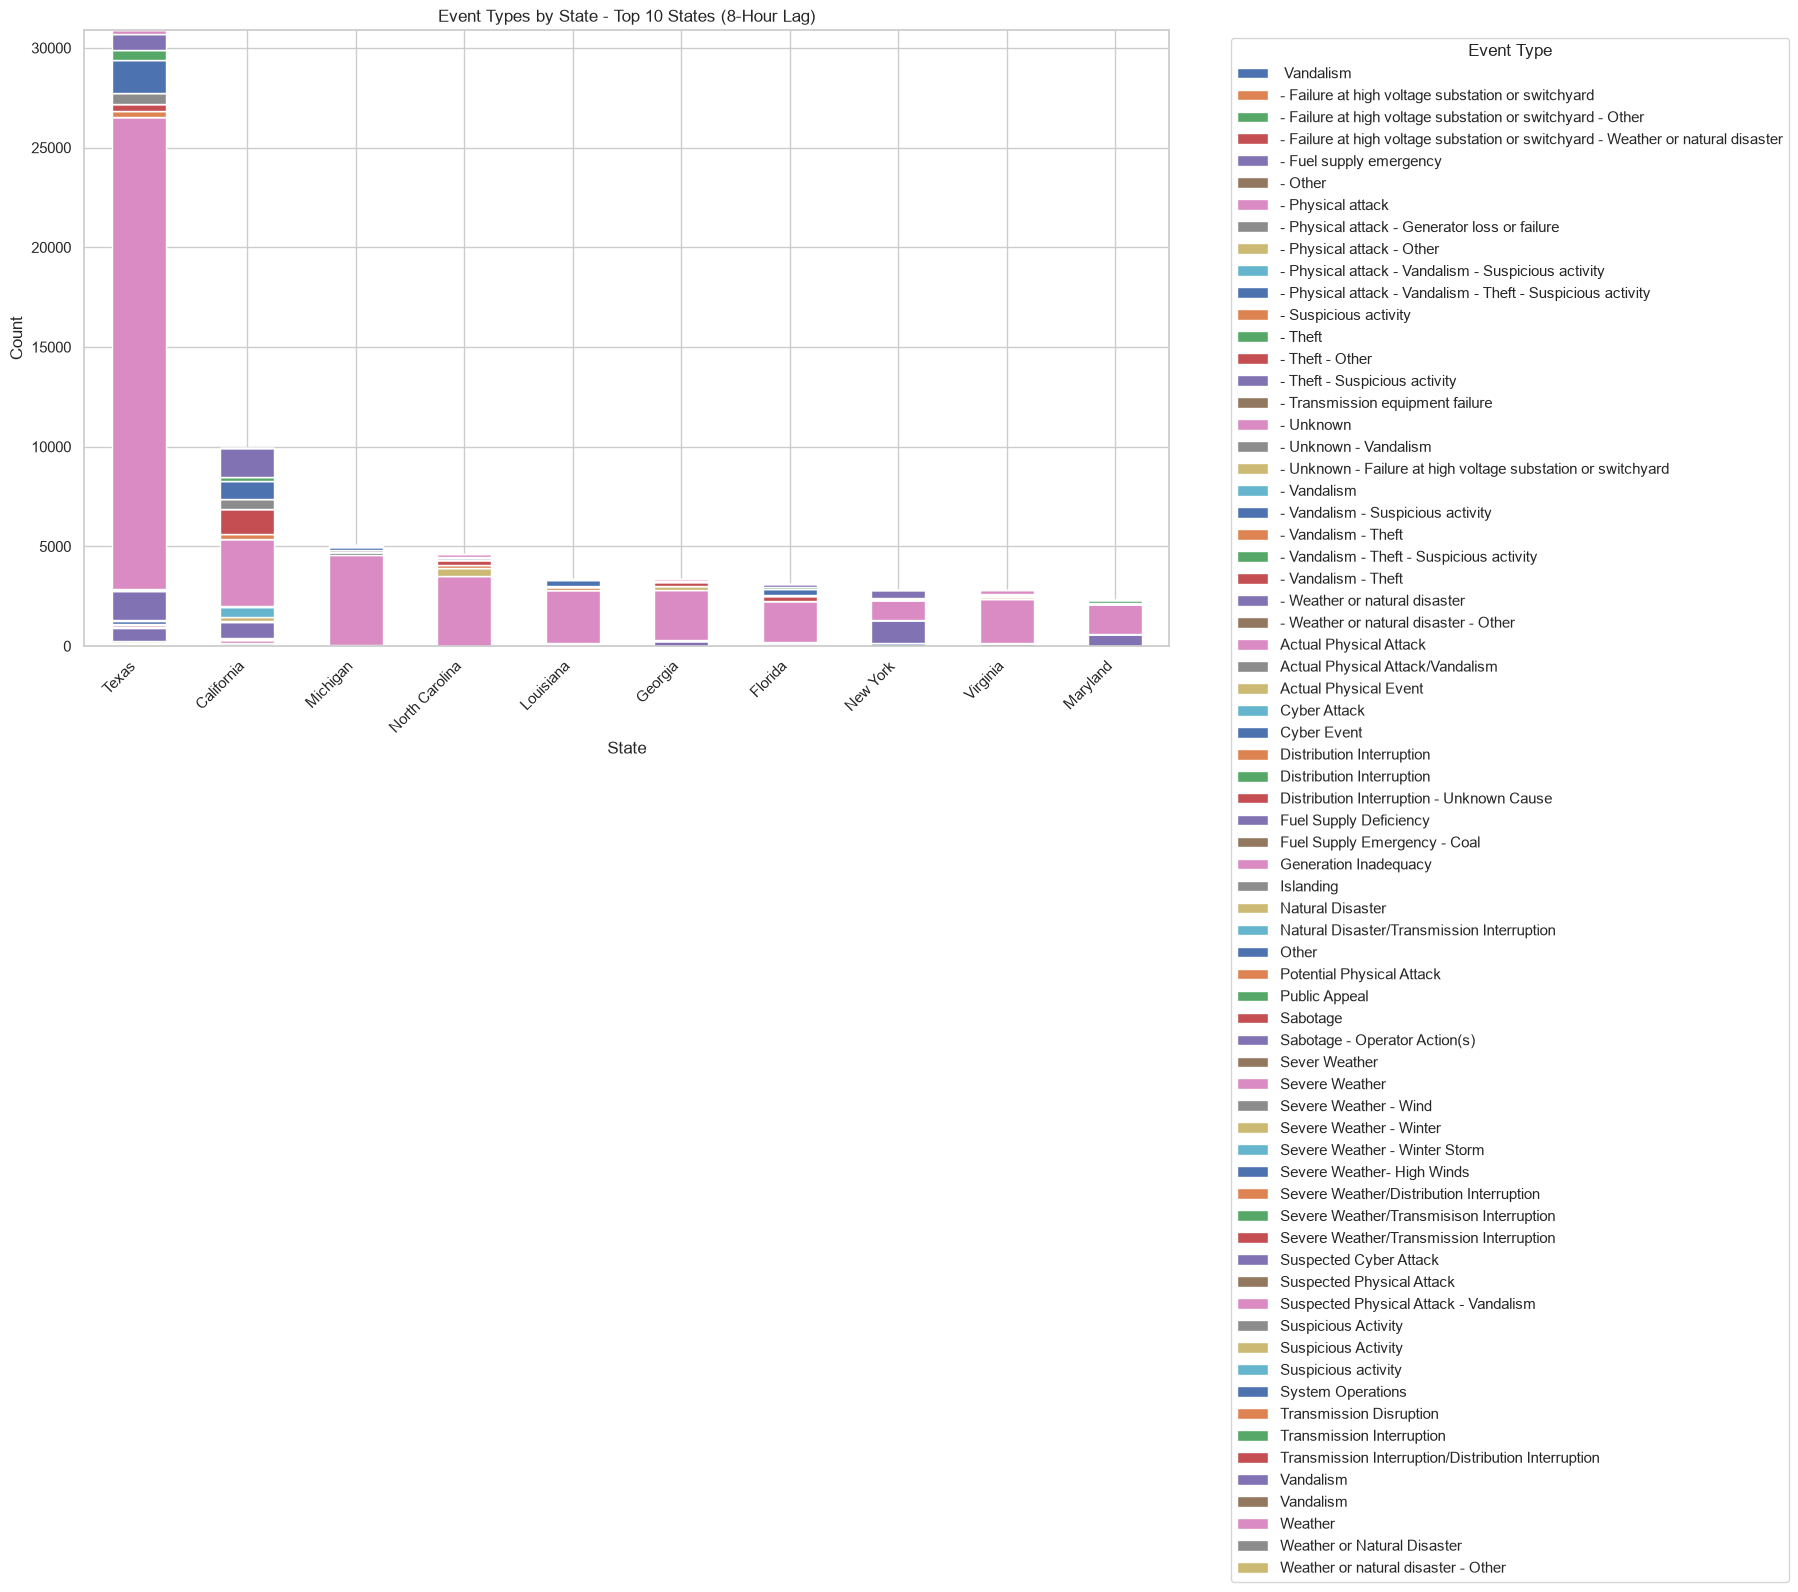

In [21]:
# Top 10 states by total outages, showing event type breakdown
top_states = state_counts.head(10).index
top_state_events = event_state_crosstab.loc[top_states]

fig, ax = plt.subplots(figsize=(14, 8))
top_state_events.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Event Types by State - Top 10 States (8-Hour Lag)')
ax.set_xlabel('State')
ax.set_ylabel('Count')
ax.legend(title='Event Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()